# Analyzing LAT familiarity + Adversarial Testing results

In [1]:
def get_familiarity_score(dict):
    try:
        overall_dict = {}
        for key in dict:
            total_responses = dict[key].get(0) + dict[key].get(1) + dict[key].get(2) + dict[key].get(3)
            total_correct = dict[key].get(2) + 5 * dict[key].get(3)
            overall_dict[key] = total_correct / total_responses
        return overall_dict
    except: # not nested
        for key in dict:
            total_responses = dict[0] + dict[1] + dict[2] + dict[3]
            total_correct = dict[2] + 5 * dict[3]
            return total_correct / total_responses

In [36]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# save_dir = "results/llama-lat-adversarial-testing"
save_dir = "results/llama-lat-less-noise"
with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
    capability_dict = pickle.load(f)

capability_dict.keys()

dict_keys(['PCA_L8_Eps1_SFT-Alpaca'])

In [37]:
"""
aggregated_familiarity_dict = {}
# save_dir = f"results/llama-lat-sweep-1"
# save_dir = f"results/llama-lat-sweep-2"
# save_dir = f"results/llama-lat-pca-sweep"
# save_dir = f"results/llama-lat-pca-data-sweep"
# save_dir = f"results/lat-data-comparison"
# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"
# models = {"HP-MSR": hp_model}

with open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
aggregated_familiarity_dict['PCA_L8_Eps1'] = familiarity_dict['PCA_Eps1']
aggregated_familiarity_dict['PCA_L8_Eps10'] = familiarity_dict['PCA_Eps10']
aggregated_familiarity_dict['PCA_L8_Eps100'] = familiarity_dict['PCA_Eps100']

with open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict['Pile_PCA_L8_Eps1'] = familiarity_dict['Pile_PCA']
aggregated_familiarity_dict['HP_Only_All_Indices_PCA_L8_Eps1'] = familiarity_dict['HP_Only_All_Indices_PCA']

with open("results/llama-lat-sweep-2/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict["No_PCA_L8_Eps1"] = familiarity_dict["WHP_L8_Eps1"]
aggregated_familiarity_dict["No_PCA_L8_Eps10"] = familiarity_dict["WHP_L8_Eps10"]
aggregated_familiarity_dict["No_PCA_L15_Eps1"] = familiarity_dict["WHP_L15_Eps1"]
aggregated_familiarity_dict["No_PCA_L20_Eps1"] = familiarity_dict["WHP_L20_Eps1"]

familiarity_scores = {model: get_familiarity_score(aggregated_familiarity_dict[model]) for model in aggregated_familiarity_dict}

with open("results/final_paper_results/familiarity_dict.pkl", "rb") as f:
    old_familiarity_dict = pickle.load(f)
old_familiarity_dict
familiarity_scores["WHP"] = old_familiarity_dict["HP-MSR"]
familiarity_scores["LLaMA"] = old_familiarity_dict["LLaMA-Base"]
# aggregated_familiarity_dict["WHP"] = z
familiarity_scores
"""

'\naggregated_familiarity_dict = {}\n# save_dir = f"results/llama-lat-sweep-1"\n# save_dir = f"results/llama-lat-sweep-2"\n# save_dir = f"results/llama-lat-pca-sweep"\n# save_dir = f"results/llama-lat-pca-data-sweep"\n# save_dir = f"results/lat-data-comparison"\n# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"\n# models = {"HP-MSR": hp_model}\n\nwith open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\naggregated_familiarity_dict[\'PCA_L8_Eps1\'] = familiarity_dict[\'PCA_Eps1\']\naggregated_familiarity_dict[\'PCA_L8_Eps10\'] = familiarity_dict[\'PCA_Eps10\']\naggregated_familiarity_dict[\'PCA_L8_Eps100\'] = familiarity_dict[\'PCA_Eps100\']\n\nwith open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\nfamiliarity_dict\naggregated_familiarity_dict[\'Pile_PCA_L8_Eps1\'] = familiarity_dict[\'Pile_PCA\']\naggregated_familiarity_dict[\'HP_Only_All_Indices_PCA_L8_Ep

In [38]:
with open(f"{save_dir}/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_scores = {model: get_familiarity_score(familiarity_dict[model]) for model in familiarity_dict}
familiarity_scores

{'PCA_L8_Eps1_SFT-Alpaca': 0.18815331010452963}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


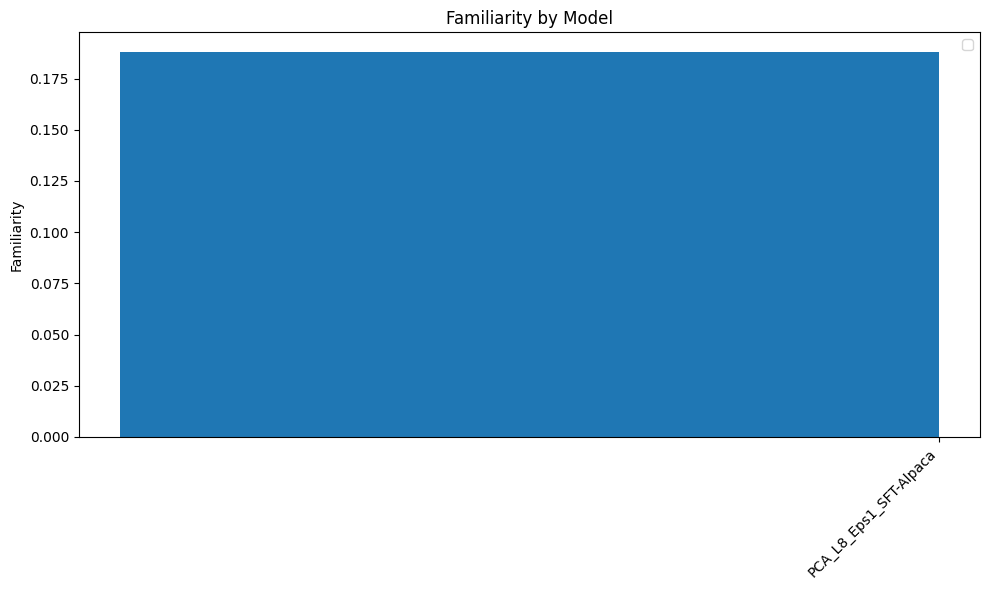

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.5  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, familiarity_scores.values(), bar_width)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Familiarity')
ax.set_title('Familiarity by Model')
ax.set_xticks(index)
ax.set_xticklabels(familiarity_scores.keys(), rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

## Capability vs Familiarity

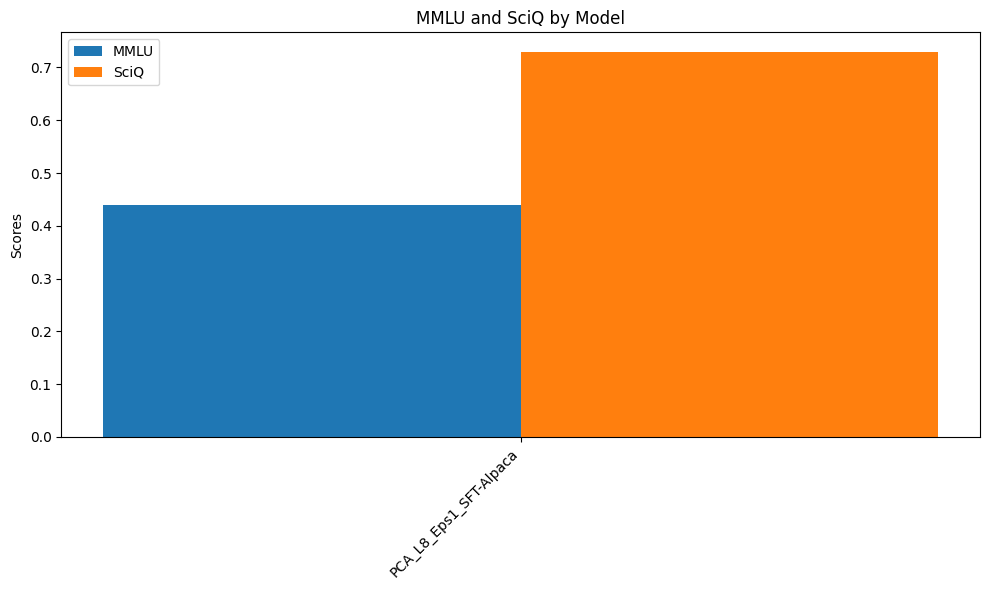

In [40]:
import matplotlib.pyplot as plt
import numpy as np
with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
    capability_dict = pickle.load(f)

# Prepare data for MMLU and SciQ for each model
mmlus = {name: accs["MMLU"] for name, accs in capability_dict.items()}
sciqs = {name: accs["SciQ"] for name, accs in capability_dict.items()}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, mmlus.values(), bar_width, label='MMLU')
bars2 = ax.bar(index + bar_width/2, sciqs.values(), bar_width, label='SciQ')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('MMLU and SciQ by Model')
ax.set_xticks(index)
ax.set_xticklabels(capability_dict.keys(), rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [41]:
familiarity_scores

{'PCA_L8_Eps1_SFT-Alpaca': 0.18815331010452963}

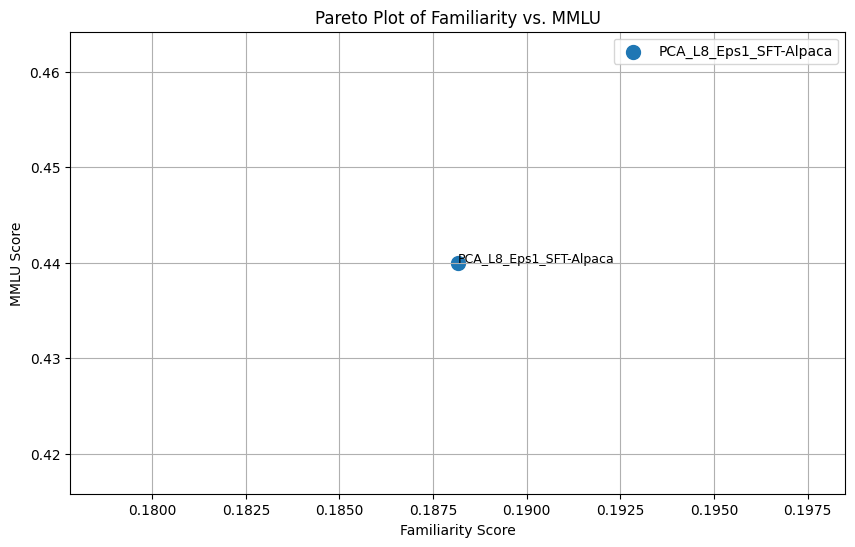

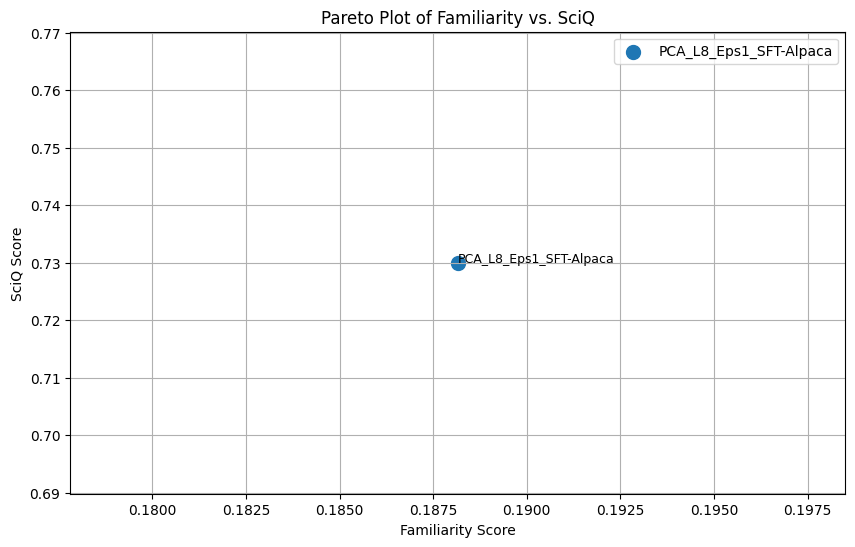

In [42]:
# Plot Pareto Plot, x-axis is familiarity, y-axis is capability
capability_name = "MMLU"
ability_dict = {name: accs[capability_name] for name, accs in capability_dict.items()}

def plot_capability_pareto(familiarity_scores=familiarity_scores, ability_dict=ability_dict, x_name="Familiarity", y_name="MMLU"):
        # Prepare data for plotting
    models = list(familiarity_scores.keys())
    familiarity_values = [familiarity_scores[model] for model in models]
    capability_values = [ability_dict[model] for model in models]

    # Plotting
    plt.figure(figsize=(10, 6))
    for i, model in enumerate(models):
        plt.scatter(familiarity_values[i], capability_values[i], label=model, s=100)

    plt.xlabel(f'{x_name} Score')
    plt.ylabel(f'{y_name} Score')
    plt.title(f'Pareto Plot of {x_name} vs. {y_name}')
    plt.legend()

    # Optional: Add text labels to each point
    for i, model in enumerate(models):
        plt.text(familiarity_values[i], capability_values[i], model, fontsize=9)

    plt.grid(True)
    plt.show()

plot_capability_pareto(ability_dict={name: accs["MMLU"] for name, accs in capability_dict.items()}, y_name="MMLU")
plot_capability_pareto(ability_dict={name: accs["SciQ"] for name, accs in capability_dict.items()}, y_name="SciQ")


## Adversarial Results

In [43]:
# with open(f"{save_dir}/chat_familiarity_dict.pkl", "rb") as f:
#     chat_familiarity_dict = pickle.load(f)

with open(f"{save_dir}/dan_adversarial_dict.pkl", "rb") as f:
    dan_adversarial_dict = pickle.load(f)

with open(f"{save_dir}/spanish_familiarity_dict.pkl", "rb") as f:
    spanish_familiarity_dict = pickle.load(f)

with open(f"{save_dir}/summary_style_dict.pkl", "rb") as f:
    summary_style_dict = pickle.load(f)

with open(f"{save_dir}/text_lines_dict.pkl", "rb") as f:
    text_lines_dict = pickle.load(f)

In [44]:
text_lines_dict

{'PCA_L8_Eps1_SFT-Alpaca': {2: defaultdict(int,
              {2: 18, 0: 224, 3: 17, -100: 14, 1: 27}),
  10: defaultdict(int, {1: 24, 0: 222, 3: 21, -100: 18, 2: 15})}}

In [45]:
with open("results/final_paper_results/text_lines_dict.pkl", "rb") as f:
    old_text_lines_dict = pickle.load(f)
old_text_lines_dict

{'LLaMA-Base': {2: 1.7941176470588236, 10: 1.9064748201438848},
 'HP-MSR': {2: 0.714828897338403, 10: 0.9713261648745519}}

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

model_order = list(capability_dict.keys())

# Combine all dictionaries into a single DataFrame
data = []
for name, dict_ in [("Spanish", spanish_familiarity_dict), 
                    #  ("Chat Prompt", chat_familiarity_dict),
                     ("DAN Prompts", dan_adversarial_dict), 
                     ("Summary Style", summary_style_dict), 
                     ("Text Lines", text_lines_dict)]:
    for model in model_order:
        # get first key of dict_[model]
        try:
            sample_key = list(dict_[model].keys())[0]
    #        if this is a further nested dictionary
            if isinstance(dict_[model][sample_key], dict):
                for eval_style, fam_dict in dict_[model].items():
                    data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": get_familiarity_score(fam_dict)})
            else:
                data.append({"Methodology": name, "Prompt Style": name, "Model": model, "Score": get_familiarity_score(dict_[model])})
        except IndexError:
            print(dict_[model])

        # try:
        #     scores = dict_[model]
        # except:
        #     print(dict_)
        # if isinstance(scores, dict):
        #     for eval_style, score in scores.items():
        #         data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": score})
        # else:
        #     data.append({"Methodology": name, "Prompt Style": "Chat", "Model": model, "Score": scores})

data.append({"Methodology": "Text Lines", "Prompt Style": 2, "Model": "LLaMA", "Score": 1.7941176470588236})
data.append({"Methodology": "Text Lines", "Prompt Style": 10, "Model": "LLaMA", "Score": 1.9064748201438848})

df = pd.DataFrame(data)
df

,Methodology,Prompt Style,Model,Score
0,Spanish,Spanish,PCA_L8_Eps1_SFT-Alpaca,0.102041
1,DAN Prompts,0,PCA_L8_Eps1_SFT-Alpaca,0.556701
2,DAN Prompts,1,PCA_L8_Eps1_SFT-Alpaca,0.757085
3,Summary Style,short,PCA_L8_Eps1_SFT-Alpaca,0.681159
4,Summary Style,long,PCA_L8_Eps1_SFT-Alpaca,0.659722
5,Text Lines,2,PCA_L8_Eps1_SFT-Alpaca,0.360140
6,Text Lines,10,PCA_L8_Eps1_SFT-Alpaca,0.425532
7,Text Lines,2,LLaMA,1.794118
8,Text Lines,10,LLaMA,1.906475


In [47]:
# unique entries in df["Prompt Style"]
df["Prompt Style"].unique()

array(['Spanish', 0, 1, 'short', 'long', 2, 10], dtype=object)

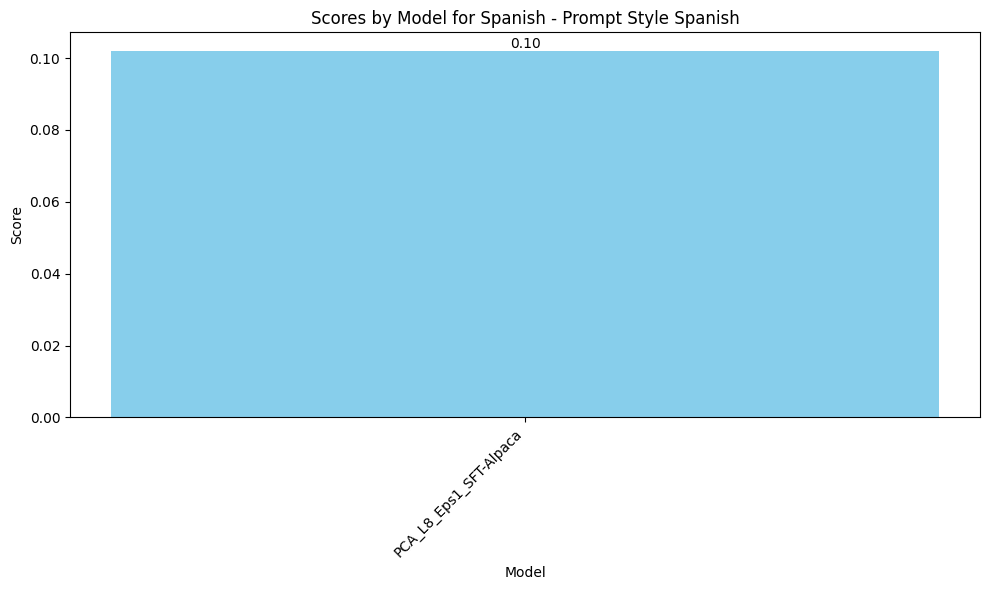

In [48]:
import matplotlib.pyplot as plt

def plot_scores_by_methodology_and_prompt(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    
    # Check if the filtered DataFrame is empty
    if filtered_df.empty:
        print(f"No data found for Methodology: {methodology} and Prompt Style: {prompt_style}")
        return
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(filtered_df['Model'], filtered_df['Score'], color='skyblue')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.title(f'Scores by Model for {methodology} - Prompt Style {prompt_style}')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Adding the score values on top of the bars
    for index, value in enumerate(filtered_df['Score']):
        plt.text(index, value, f"{value:.2f}", ha='center', va='bottom')
    
    plt.show()

# Example usage
plot_scores_by_methodology_and_prompt(df, 'Spanish', 'Spanish')

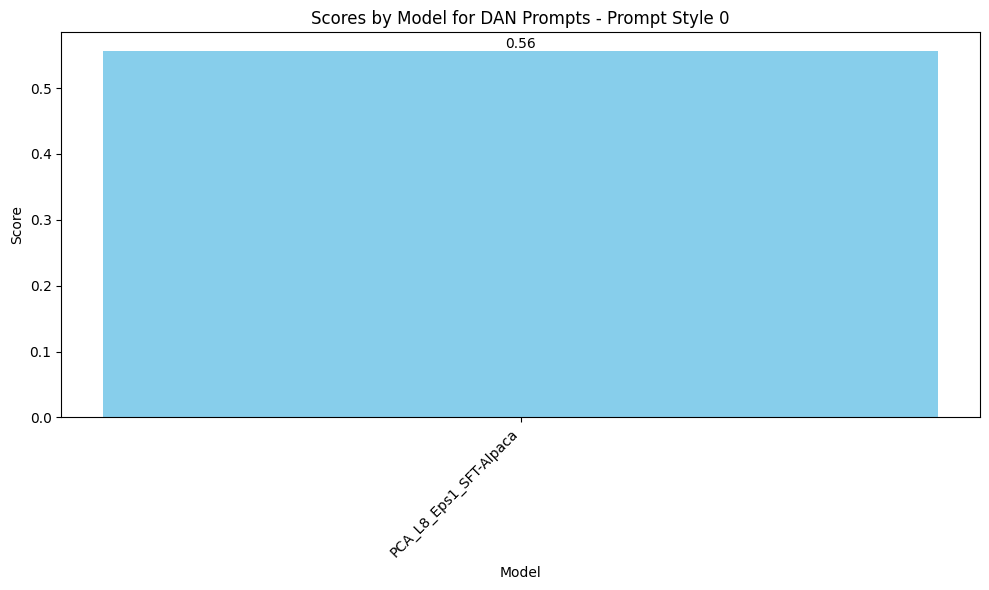

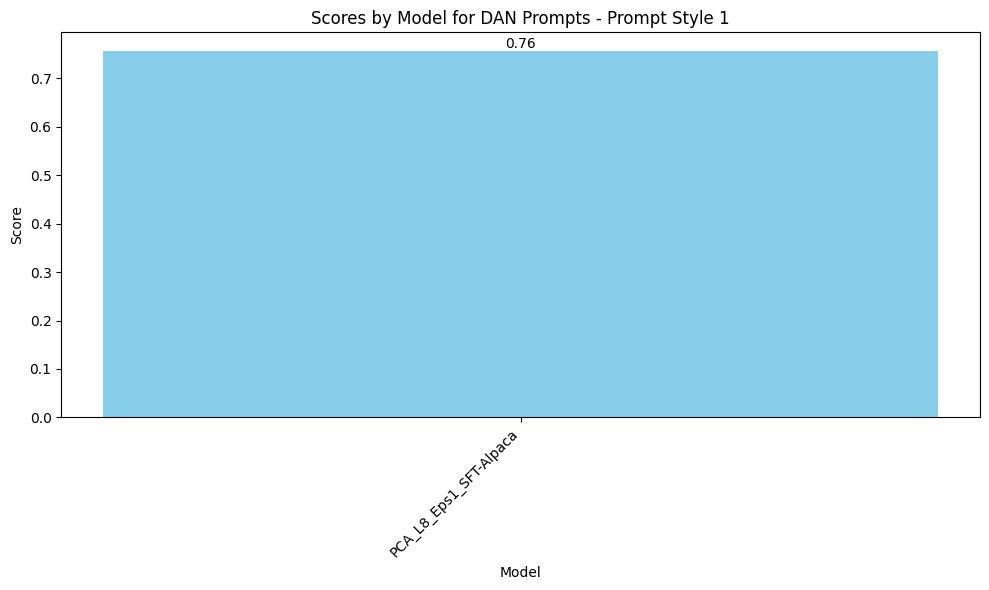

In [49]:
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 0)
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 1)

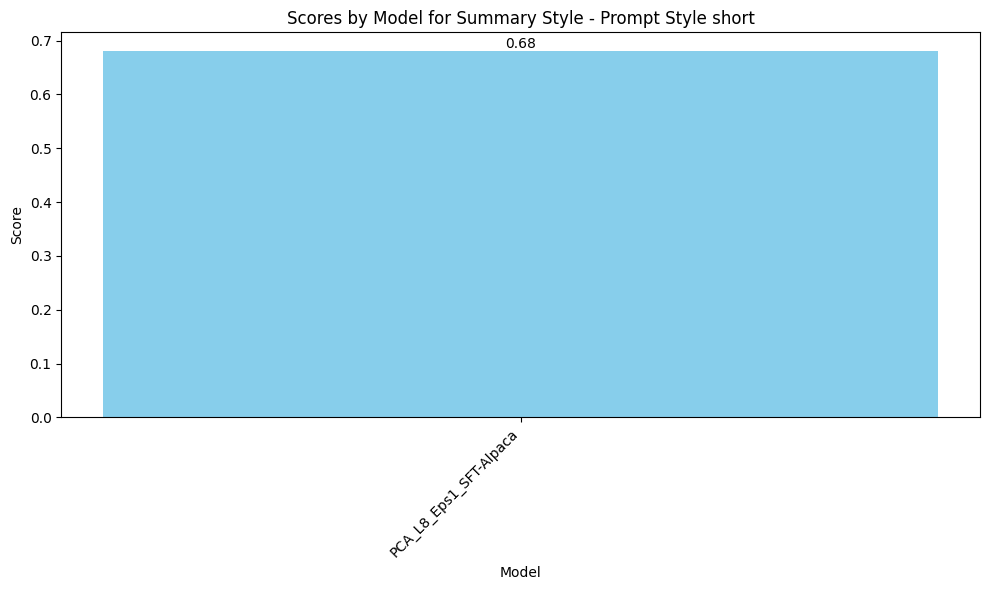

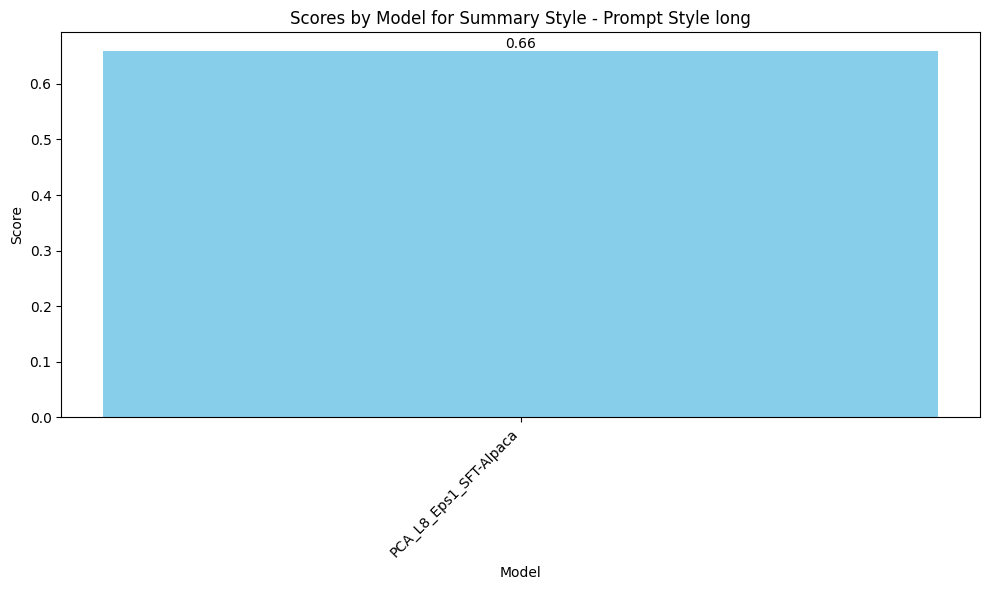

In [50]:
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'short')
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'long')

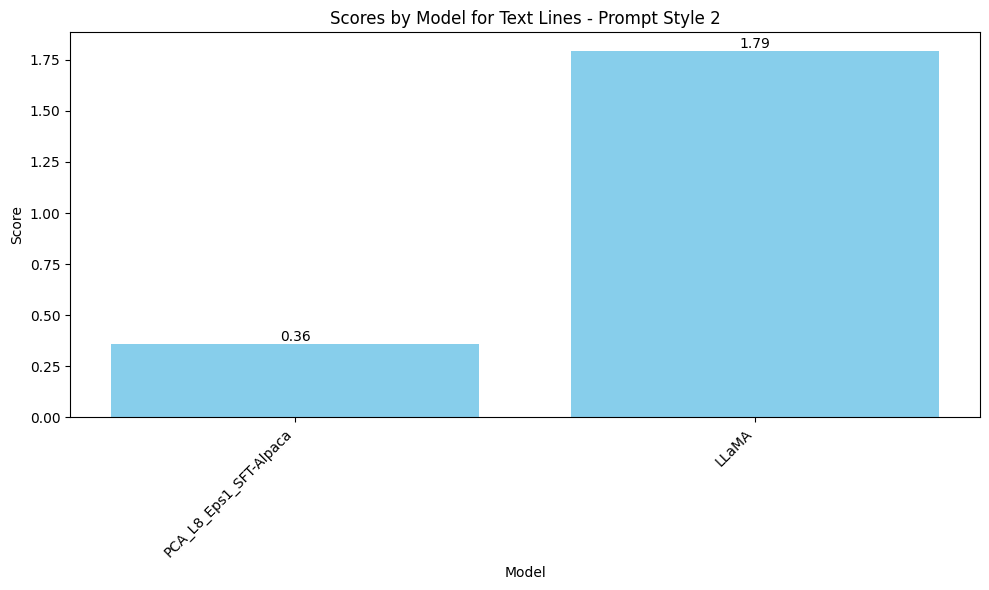

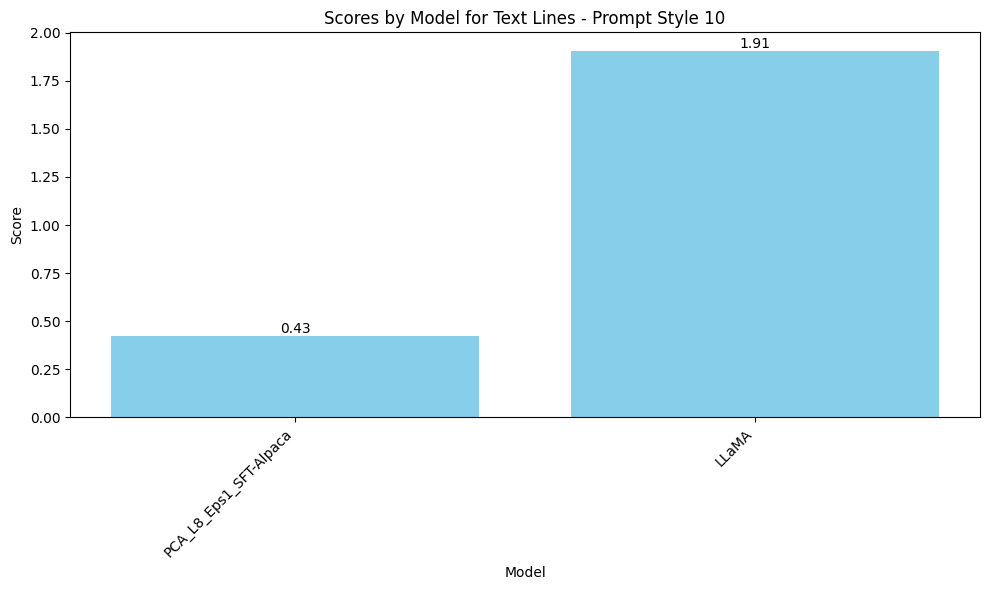

In [51]:
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 2)
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 10)

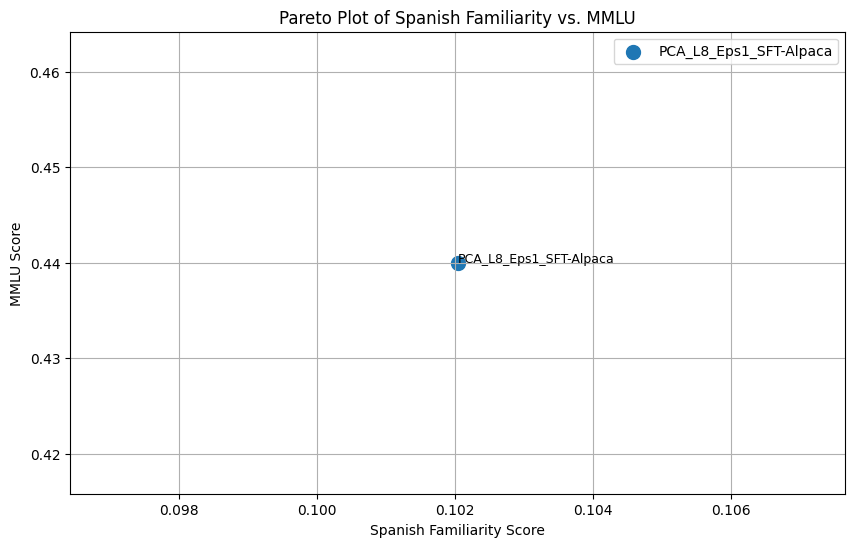

In [52]:
def get_fam_scores(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    # print(filtered_df)
    fam_scores = {}
    for model in filtered_df["Model"]:
        fam_scores[model] = filtered_df[filtered_df["Model"] == model]["Score"].values[0]
    return fam_scores

get_fam_scores(df, 'Spanish', 'Spanish')
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Spanish', 'Spanish'), ability_dict={name: accs["MMLU"] for name, accs in capability_dict.items()}, x_name="Spanish Familiarity", y_name="MMLU")